# CatalogIQ - Notebook 01: Understanding our data

**What is CatalogIQ?** An AI assistant for online marketplaces. Small sellers often upload products with
poor photos, wrong categories, missing details and thin descriptions - which hurts search, sales and
returns. CatalogIQ looks at a product photo, fills in the product details, writes the listing text, and
answers shoppers' questions using real reviews.

**What is this notebook?** Before building anything, we look at the two datasets we will learn from and
ask five business questions:

1. How lopsided is our product data, and what does that mean for the photo classifier?
2. Which product details are most often missing or inconsistent in a real catalog?
3. What do the best-rated listings do differently in their text?
4. What do shoppers actually ask about or complain about in reviews?
5. What do the products look like? (a visual sanity check)

Every chart is followed by a plain-language takeaway. All data-handling logic lives in `src/catalogiq/`;
this notebook only calls it and draws charts.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from catalogiq.config import get_config, resolve_path
from catalogiq.data.fashion import image_path
from catalogiq.data.text_stats import REVIEW_TOPICS, listing_profile, topic_share

cfg = get_config()
FIG = resolve_path(cfg["paths"]["reports_figures"])
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
BLUE, ORANGE, GREY = "#2f6fb0", "#e07b39", "#8a8f98"

raw = pd.read_parquet(resolve_path(cfg["data"]["fashion"]["audit_parquet"]))
clean = pd.read_parquet(resolve_path(cfg["data"]["fashion"]["clean_parquet"]))
items = pd.read_parquet(resolve_path(cfg["data"]["reviews"]["meta_parquet"]))
reviews = pd.read_parquet(resolve_path(cfg["data"]["reviews"]["reviews_parquet"]))
evidence = pd.read_csv(resolve_path("reports/target_evidence.csv"))
TARGETS = cfg["data"]["fashion"]["taxonomy"]
print(f"Fashion catalog: {len(raw):,} rows raw -> {len(clean):,} after cleaning")
print(f"Amazon sample:   {len(items):,} listings, {len(reviews):,} reviews")

Fashion catalog: 44,446 rows raw -> 42,257 after cleaning
Amazon sample:   800 listings, 139,400 reviews


## The two datasets in one paragraph

* **Fashion Product Images (Kaggle)** - ~44k small product photos, each labelled by a professional catalog
  team with 7 attributes (category, sub-category, product type, colour, gender, season, usage). This is where
  our *photo classifier* learns. It is clean, which makes it the "answer key".
* **Amazon Fashion (McAuley Lab)** - real marketplace listings written by sellers, with real shopper reviews.
  It is messy like the real world, so it shows us what small-seller catalogs look like and what shoppers care
  about. We sampled the 800 most-reviewed listings (at least 20 reviews each), ~139k reviews.

## 1. How lopsided is our product data?

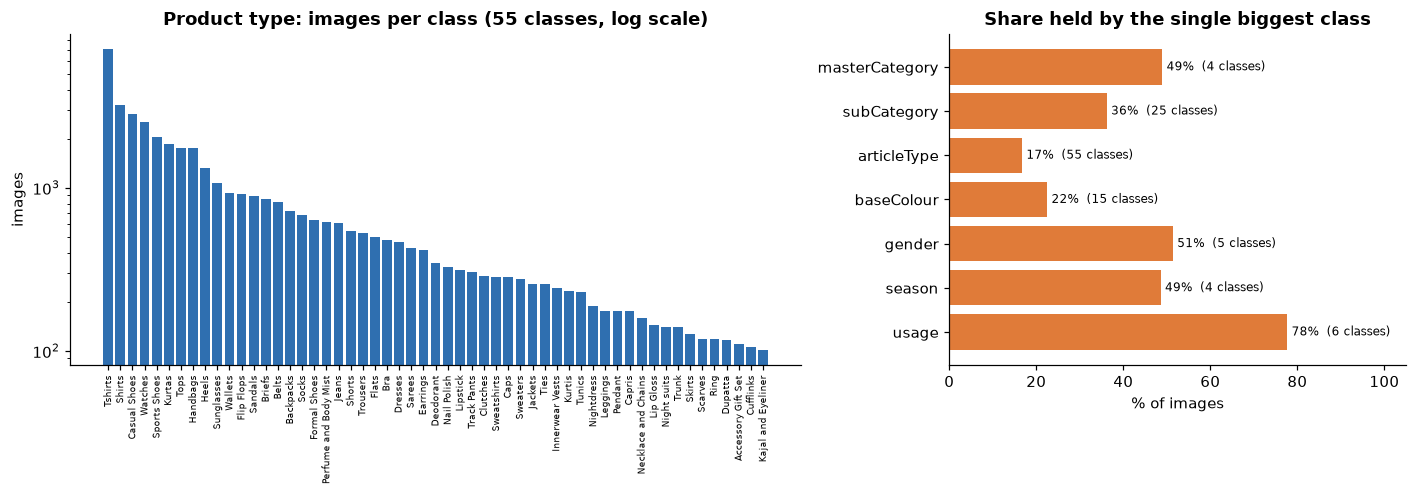

biggest : smallest class ratio per target
  masterCategory  20,689 : 1,850  = 11x   (top class: Apparel)
  subCategory     15,293 :   106  = 144x   (top class: Topwear)
  articleType      7,069 :   102  = 69x   (top class: Tshirts)
  baseColour       9,506 :    56  = 170x   (top class: Black)
  gender          21,722 :   627  = 35x   (top class: Men)
  season          20,523 : 2,422  = 8x   (top class: Summer)
  usage           32,826 :   112  = 293x   (top class: Casual)

product types dropped as too rare (<100 images): 88 classes
majority-class accuracy a 'lazy' model gets for usage: 77.7%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.6, 1]})
vc = clean["articleType"].value_counts()
axes[0].bar(range(len(vc)), vc.values, color=BLUE)
axes[0].set_yscale("log")
axes[0].set_xticks(range(0, len(vc), 1)); axes[0].set_xticklabels(vc.index, rotation=90, fontsize=6)
axes[0].set_title(f"Product type: images per class ({len(vc)} classes, log scale)")
axes[0].set_ylabel("images")

ev = evidence.set_index("target").loc[TARGETS]
axes[1].barh(ev.index[::-1], ev["majority_share"][::-1] * 100, color=ORANGE)
for y, (share, n) in enumerate(zip(ev["majority_share"][::-1] * 100, ev["n_classes"][::-1])):
    axes[1].text(share + 1, y, f"{share:.0f}%  ({n} classes)", va="center", fontsize=8)
axes[1].set_xlim(0, 105)
axes[1].set_title("Share held by the single biggest class")
axes[1].set_xlabel("% of images")
plt.tight_layout(); plt.savefig(FIG / "01_class_imbalance.png", bbox_inches="tight"); plt.show()

vc_all = {t: clean[t].value_counts() for t in TARGETS}
print("biggest : smallest class ratio per target")
for t, v in vc_all.items():
    print(f"  {t:15s} {v.iloc[0]:>6,} : {v.iloc[-1]:>5,}  = {v.iloc[0] / v.iloc[-1]:,.0f}x   (top class: {v.index[0]})")
print("\nproduct types dropped as too rare (<100 images):",
      f"{raw['articleType'].nunique() - clean['articleType'].nunique()} classes")
print("majority-class accuracy a 'lazy' model gets for usage:", f"{clean['usage'].value_counts(normalize=True).iloc[0]:.1%}")

**What we learned:** The data is very lopsided. The most common product type (T-shirts) has 7,069 photos while the rarest kept type has 102 - a 69x gap - and 88 product types with fewer than 100 photos were set aside as too rare. Usage is the extreme case: 78% of products are "Casual", so a lazy model that always answers "Casual" would already be right 77.7% of the time. Gender is similar (51% Men).

**Business takeaway:** Plain accuracy would flatter the classifier, so we will judge every target against its "always guess the biggest class" baseline and report per-class results (macro-F1), not just overall accuracy. A seller-facing tool also cannot promise product types it has barely seen: for the 88 rare types we would rather say "I'm not sure, please choose" than guess wrong, which is why they are excluded from training and handled by a confidence threshold later.

## 2. Which details are missing or inconsistent in a real catalog?

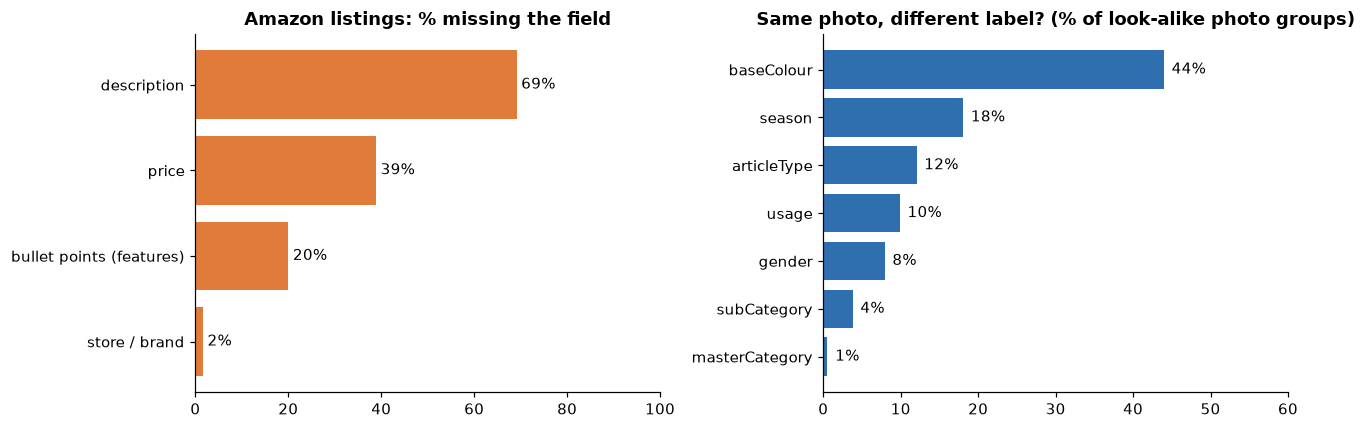

Fashion catalog (professionally curated) raw missing values:
season        21
year           1
usage          1
baseColour     0

raw colour names: 47  ->  retail palette: 15
raw product types: 143  ->  kept: 55
photo groups checked for label agreement: 1,478
images with a look-alike twin: 3,932


In [3]:
fields = {"description": (items["description"].str.len() == 0),
          "price": items["price"].isna(),
          "bullet points (features)": items["features"].map(len) == 0,
          "store / brand": items["store"].str.len() == 0}
miss = pd.Series({k: v.mean() * 100 for k, v in fields.items()}).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(miss.index, miss.values, color=ORANGE)
for y, v in enumerate(miss.values): axes[0].text(v + 1, y, f"{v:.0f}%", va="center")
axes[0].set_xlim(0, 100); axes[0].set_title("Amazon listings: % missing the field")

tw = evidence.set_index("target").loc[TARGETS, "twin_disagreement"].sort_values() * 100
axes[1].barh(tw.index, tw.values, color=BLUE)
for y, v in enumerate(tw.values): axes[1].text(v + 1, y, f"{v:.0f}%", va="center")
axes[1].set_xlim(0, 60)
axes[1].set_title("Same photo, different label? (% of look-alike photo groups)")
plt.tight_layout(); plt.savefig(FIG / "02_missing_and_inconsistent.png", bbox_inches="tight"); plt.show()

print("Fashion catalog (professionally curated) raw missing values:")
print(raw[["season", "year", "usage", "baseColour"]].isna().sum().to_string())
print(f"\nraw colour names: {raw['baseColour'].nunique()}  ->  retail palette: {clean['baseColour'].nunique()}")
print(f"raw product types: {raw['articleType'].nunique()}  ->  kept: {clean['articleType'].nunique()}")
print(f"photo groups checked for label agreement: {int(evidence['twin_groups'].iloc[0]):,}")
print(f"images with a look-alike twin: {int((raw['dup_group'].map(raw['dup_group'].value_counts()) >= 2).sum()):,}")

**What we learned (left chart):** In real seller-written Amazon listings, 69% have no description, 39% show no price, 20% have no bullet points and 2% name no brand. By contrast, the professionally curated fashion catalog is almost complete (21 missing seasons and 1 missing usage across 44,446 products). **(Right chart):** even a professional catalog is not perfectly consistent - in groups of near-identical photos, 44% disagree on colour, 18% on season, 12% on product type, 10% on usage, 8% on gender and under 1% on top-level category. Colour disagreement is partly legitimate (the same product in different colourways looks alike to our duplicate detector) and partly a naming problem: the catalog uses 47 colour names, which we collapsed to a 15-colour retail palette.

**Business takeaway:** This is the business case for CatalogIQ - the gaps are in exactly the fields that drive search and conversion (description, bullets, price). It also sets a realistic ceiling: where humans disagree with themselves (season, usage, colour shades) no model can be expected to score near 100%, so we will not promise it.

## 3. What do the best-rated listings do differently?

**How we define "performing well":** a listing with a high *shrunk* rating (our quality score, see
`docs/decisions.md`) AND at least 50 ratings. We deliberately do **not** require complete text in this
definition, so the comparison below is not circular. Attribute mentions are simple keyword checks
(materials, fit, care, occasion, size) on title + bullets + description.

performing listings: 224 of 800


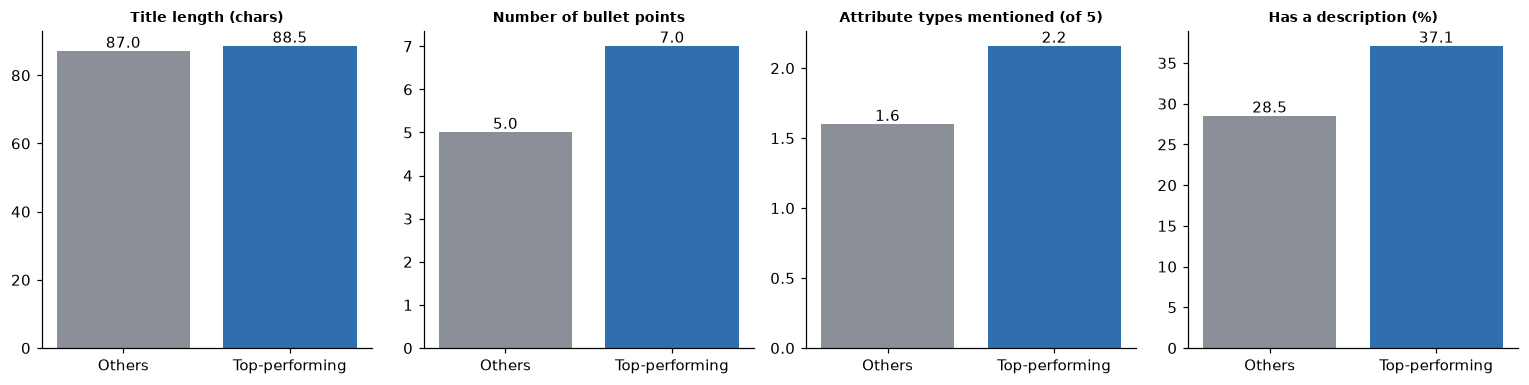

                                  others  top-performing
Title length (chars)               87.00           88.50
Number of bullet points             5.00            7.00
Attribute types mentioned (of 5)    1.60            2.16
Has a description (%)              28.47           37.05

% of listings mentioning each attribute type
performs            others  top-performing
mentions_material     35.0            55.0
mentions_fit          15.0            17.0
mentions_care         32.0            49.0
mentions_occasion     32.0            41.0
mentions_size_info    44.0            54.0


In [4]:
q = cfg["listing_quality"]
items["performs"] = (items["quality_score"] >= q["exemplar_min_score"]) & (items["rating_number"] >= q["exemplar_min_ratings"])
prof = listing_profile(items)
prof["performs"] = items["performs"].values
prof["has_description"] = prof["description_chars"] > 0
print("performing listings:", int(items["performs"].sum()), "of", len(items))

metrics = {"Title length (chars)": ("title_chars", "median"),
           "Number of bullet points": ("n_bullets", "median"),
           "Attribute types mentioned (of 5)": ("n_attribute_families", "mean"),
           "Has a description (%)": ("has_description", "pct")}
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
summary = {}
for ax, (title, (col, how)) in zip(axes, metrics.items()):
    g = prof.groupby("performs")[col]
    vals = (g.mean() * 100) if how == "pct" else (g.median() if how == "median" else g.mean())
    vals = vals.reindex([False, True])
    summary[title] = vals.round(2).to_dict()
    ax.bar(["Others", "Top-performing"], vals.values, color=[GREY, BLUE])
    for x, v in enumerate(vals.values): ax.text(x, v, f"{v:.1f}", ha="center", va="bottom")
    ax.set_title(title, fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "03_top_vs_other_listings.png", bbox_inches="tight"); plt.show()
print(pd.DataFrame(summary).T.rename(columns={False: "others", True: "top-performing"}))

fams = [c for c in prof if c.startswith("mentions_")]
print("\n% of listings mentioning each attribute type")
print((prof.groupby("performs")[fams].mean().T * 100).round(0).rename(columns={False: "others", True: "top-performing"}))

**What we learned:** Of 800 sampled listings, 224 qualify as top-performing (high shrunk rating plus at least 50 ratings). Compared with the rest, they carry more bullet points (median 7 vs 5), mention more kinds of product attributes (2.2 vs 1.6 out of 5 types), more often name the material (55% vs 35%), care instructions (49% vs 32%) and size information (54% vs 44%), and more often include a description (37% vs 28%). Title length is essentially the same (88.5 vs 87 characters), so a longer title is not the lever. Even the best listings rarely mention fit (17%).

**Business takeaway:** Good copy is complete, not longer: concrete facts about material, care, size and occasion. The listing generator should therefore always cover those fact types - but only when they are known from the photo, the seller's input or retrieved similar listings - and must never invent them. Caveat: this is an association, not proof that these words cause better ratings (well-known brands may simply write fuller listings).

## 4. What do shoppers ask about or complain about?

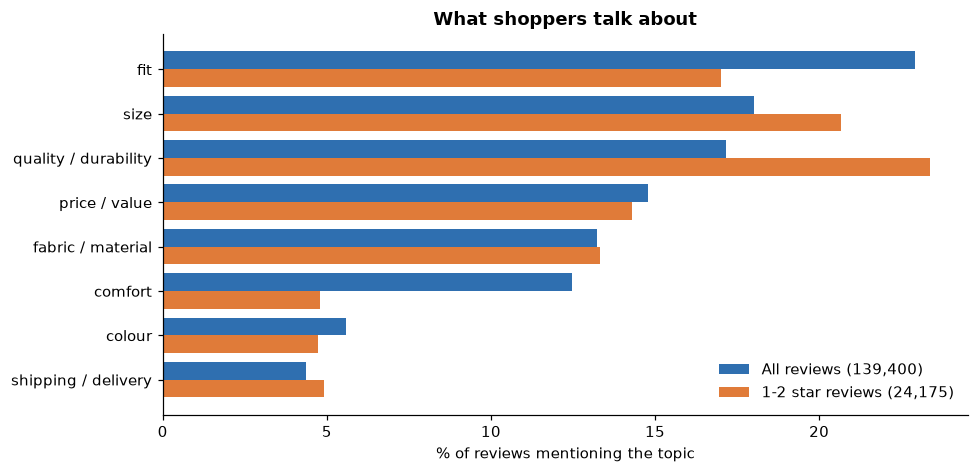

                       all  1-2 star
fit                   22.9      17.0
size                  18.0      20.7
quality / durability  17.2      23.4
price / value         14.8      14.3
fabric / material     13.2      13.3
comfort               12.5       4.8
colour                 5.6       4.7
shipping / delivery    4.4       4.9

rating mix: {1.0: 11.0, 2.0: 6.3, 3.0: 9.4, 4.0: 14.0, 5.0: 59.2}
verified purchases: 96%


In [5]:
all_share = topic_share(reviews) * 100
low = reviews[reviews["rating"] <= 2]
low_share = topic_share(low) * 100
order = all_share.sort_values().index
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(y + 0.2, all_share[order], height=0.4, color=BLUE, label=f"All reviews ({len(reviews):,})")
ax.barh(y - 0.2, low_share[order], height=0.4, color=ORANGE, label=f"1-2 star reviews ({len(low):,})")
ax.set_yticks(y); ax.set_yticklabels(order)
ax.set_xlabel("% of reviews mentioning the topic"); ax.legend(frameon=False)
ax.set_title("What shoppers talk about")
plt.tight_layout(); plt.savefig(FIG / "04_review_topics.png", bbox_inches="tight"); plt.show()
print(pd.DataFrame({"all": all_share.round(1), "1-2 star": low_share.round(1)}).sort_values("all", ascending=False))
print("\nrating mix:", (reviews["rating"].value_counts(normalize=True).sort_index() * 100).round(1).to_dict())
print("verified purchases:", f"{reviews['verified_purchase'].mean():.0%}")

**What we learned:** Across 139,400 reviews, the most discussed topics are fit (23% of reviews), size (18%), quality/durability (17%), price/value (15%) and fabric (13%); colour (6%) and shipping (4%) come up much less. In the 24,175 low-rated (1-2 star) reviews, quality/durability is mentioned more (23% vs 17% overall) and so is size (21% vs 18%), while comfort is mentioned far less (5% vs 12.5% overall). Note this is keyword counting and cannot tell "fits perfectly" from "doesn't fit".

**Business takeaway:** Shoppers' questions will overwhelmingly be about fit, size, material and durability, so the review Q&A must be strongest there, quote the actual reviews, and say "not enough evidence" when few reviews cover the question. These topics are also what sellers' listings under-describe (fit is mentioned in under a fifth of listings), which is the opportunity.

## 5. What do the products look like?

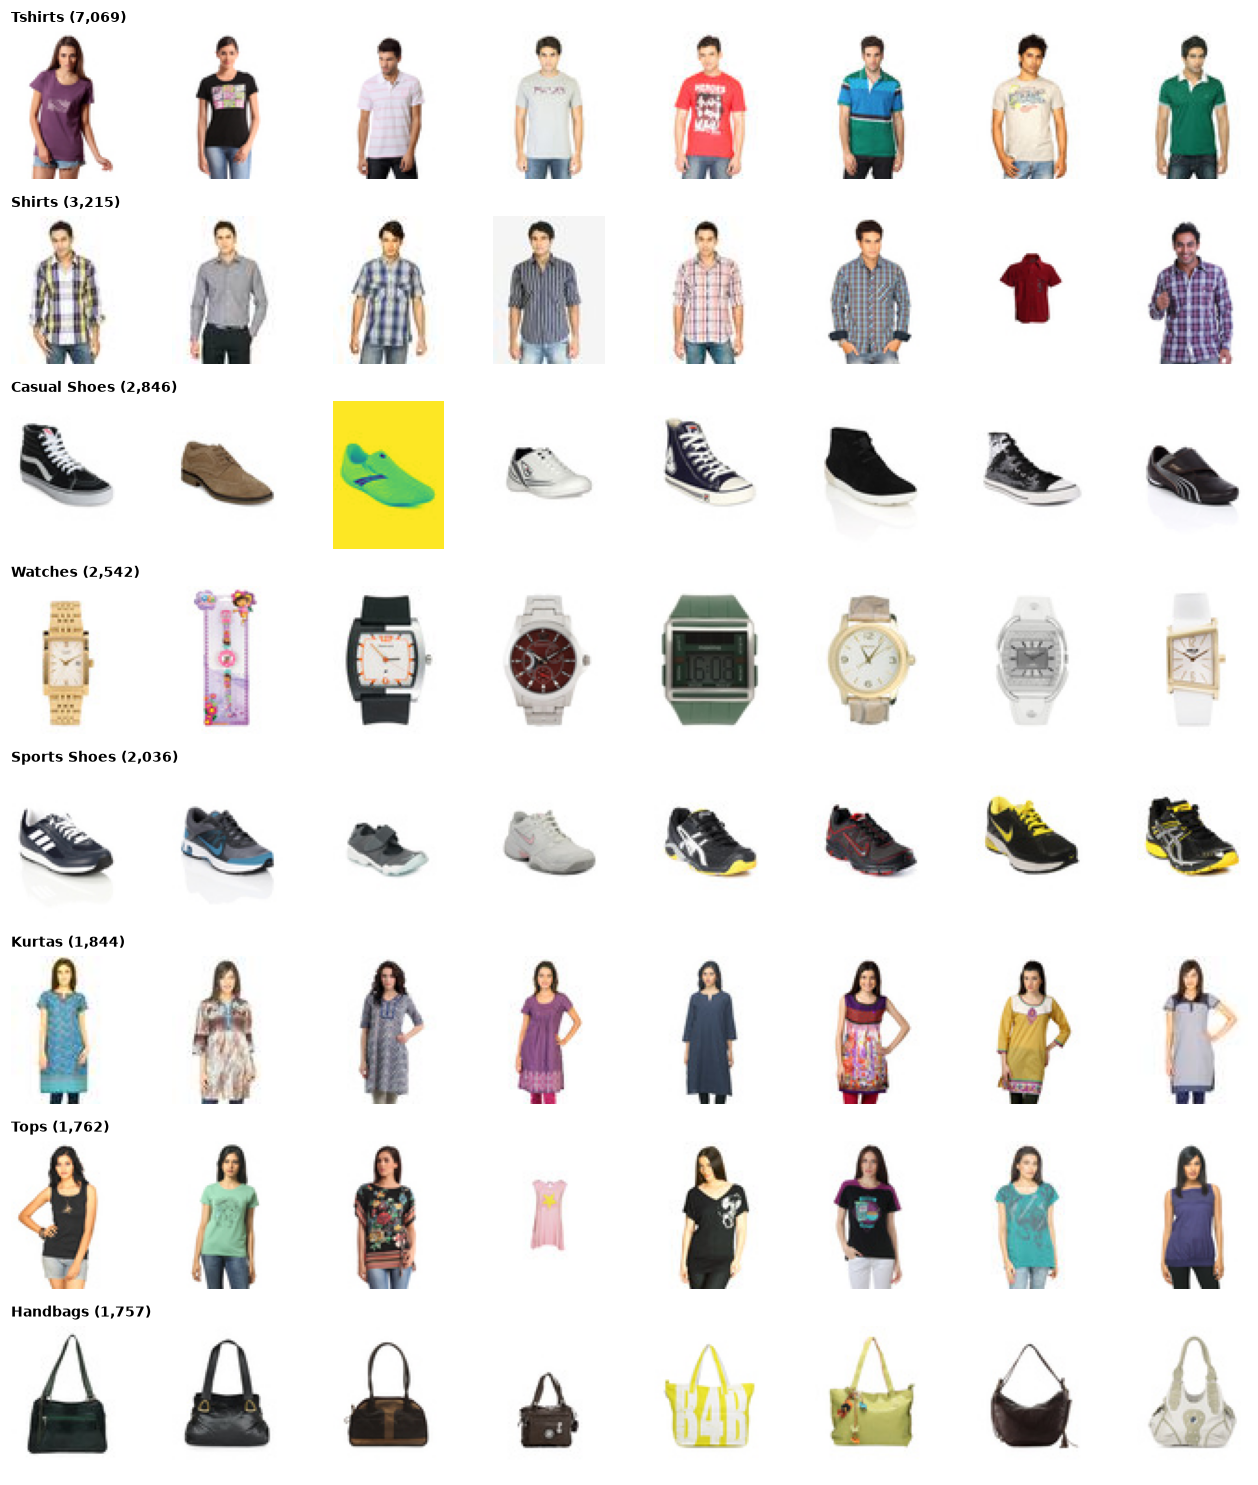

all images are [(53, 80), (54, 80), (60, 60)] pixels (width x height)


In [6]:
types = clean["articleType"].value_counts().index[:8]
rng = np.random.default_rng(cfg["project"]["seed"])
fig, axes = plt.subplots(len(types), 8, figsize=(12, 1.7 * len(types)))
for r, t in enumerate(types):
    ids = rng.choice(clean.loc[clean["articleType"] == t, "id"].to_numpy(), 8, replace=False)
    for c, pid in enumerate(ids):
        axes[r, c].imshow(Image.open(image_path(resolve_path(cfg["data"]["fashion"]["images_dir"]), pid)))
        axes[r, c].axis("off")
    axes[r, 0].set_title(f"{t} ({(clean['articleType'] == t).sum():,})", loc="left", fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "05_sample_grid.png", bbox_inches="tight"); plt.show()
print("all images are", sorted(set(zip(raw["width"][raw["image_ok"]], raw["height"][raw["image_ok"]])))[:3], "pixels (width x height)")

**What we learned:** The products are photographed in a studio style: one item per image, mostly plain white backgrounds, often worn by a model, at a small 60x80-pixel thumbnail size. Types look visually distinct (shoes vs watches vs bags) while some neighbours are genuinely similar (casual vs sports shoes, tops vs T-shirts).

**Business takeaway:** A model trained on this "catalog quality" photography will probably do worse on a small seller's phone photo with a messy background or poor light - this is a known limitation we will measure and write down rather than hide. It is also exactly why a photo-quality checker (blur, brightness, background) is a feature of the product.

## 6. Which targets should the classifier predict?

In [7]:
shown = evidence.copy()
shown["majority_share"] = (shown["majority_share"] * 100).round(1)
shown["twin_disagreement"] = (shown["twin_disagreement"] * 100).round(1)
shown = shown.rename(columns={"majority_share": "biggest class %", "pct_missing": "% missing",
                              "twin_disagreement": "look-alike photos disagree %"})
shown

,target,n_classes,biggest class %,% missing,twin_groups,look-alike photos disagree %
0,masterCategory,4,49.0,0.000,1478,0.5
1,subCategory,25,36.2,0.000,1478,3.8
2,articleType,55,16.7,0.000,1478,12.0
3,baseColour,15,22.5,0.000,1478,44.0
4,gender,5,51.4,0.000,1478,7.9
5,season,4,48.6,0.047,1478,18.1
6,usage,6,77.7,0.002,1478,9.9


**What we learned:** Combining the three signals - how dominant the biggest class is, how often humans disagree on near-identical photos, and how much is missing - the targets fall into two groups. **Reliable enough to auto-suggest:** masterCategory (0.5% disagreement), subCategory (3.8%), gender (7.9%) and articleType (12.0%, with the biggest class only 17%). **Shaky - treat as suggestions only:** baseColour (44% disagreement, partly legitimate colourways), season (18.1%; a season is hard to see in a photo) and usage (9.9% disagreement but 78% of products are "Casual", so the bar to beat is high).

**Business takeaway / decision:** We keep all seven targets for now, because they are what sellers need, but we only publish a prediction in the product if it clearly beats its always-guess-the-biggest-class baseline on the held-out test set in Phase 2. Season and usage are provisional and will be dropped or shown as low-confidence hints if the baseline shows no real gain.

## What we learned overall and what happens next

See the takeaways above. Next phase: train a baseline classifier on the cleaned splits
(`data/processed/fashion_{train,val,test}.parquet`) and measure how well each target can really be predicted.